# This notebook was used to analyze some intronless transcripts. I generated both attention plots and GRAD-CAM visualizations for two intronless transcipts

In [1]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,getDataPointList,getDataPointListFull,DataPoint
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy
from collections import OrderedDict
#import tensorflow as tf

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType)    
BATCH_SIZE=1

In [3]:
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook
NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

### Generating a list of some intronless transcripts to test

I used this quick code to generate some intronless genes from the gtf file. Specifically, trying to only keep the genes where all transcripts in the gene are intronless. However, it could be modified to instead generate all intronless transcripts. Additionally, as this was to do a quick test with a few intronless genes, it may be worth verifying that each gene in the file is indeed intronless. For my testing purposes the intronless genes I looked at I made sure to verify in ENSEMBL that they were intronless.

In [4]:
import gffutils
data_dir = '../Data/'
fasta_file_path = '../Data/genome.fa'
gtf_file_path = '../Data/Homo_sapiens.GRCh38.87.gtf'
fname = data_dir+gtf_file_path.split('/')[-1][:-4]+'.db'
db = gffutils.FeatureDB(fname)

records = []

# Iterate over all genes
for gene in db.features_of_type('gene'):
    transcripts = list(db.children(gene, featuretype='transcript'))

    if not transcripts:
        continue

    all_intronless = True
    for transcript in transcripts:
        exons = list(db.children(transcript, featuretype='exon', order_by='start'))
        if len(exons) != 1:
            all_intronless = False
            break

    if all_intronless:
        for transcript in transcripts:
            gene_attrs = gene.attributes
            tx_attrs = transcript.attributes

            try:
                name = '{}---{}.{}---{}.{}---{}'.format(
                    gene_attrs['gene_name'][0],
                    gene_attrs['gene_id'][0],
                    gene_attrs['gene_version'][0],
                    tx_attrs['transcript_id'][0],
                    tx_attrs['transcript_version'][0],
                    tx_attrs['transcript_biotype'][0]
                )
            except KeyError as e:
                print(f"Skipping transcript due to missing attribute: {e}")
                continue

            records.append({
                'name': name,
                'chrom': 'chr' + transcript.chrom,
                'strand': transcript.strand,
                'tx_start': transcript.start,
                'tx_end': transcript.end,
                'transcript': tx_attrs['transcript_id'][0],
                'gene': gene_attrs['gene_id'][0]
            })

df = pd.DataFrame(records)

df.to_csv("../Data/true_intronless_gene_transcripts.tsv", sep="\t", index=False)

print(df.head())


                                                name chrom strand  tx_start  \
0  MIR6859-1---ENSG00000278267.1---ENST0000061921...  chr1      -     17369   
1  OR4G4P---ENSG00000268020.3---ENST00000606857.1...  chr1      +     52473   
2  OR4G11P---ENSG00000240361.1---ENST00000492842....  chr1      +     62948   
3  OR4F5---ENSG00000186092.4---ENST00000335137.3-...  chr1      +     69091   
4  CICP27---ENSG00000233750.3---ENST00000442987.3...  chr1      +    131025   

   tx_end       transcript             gene  
0   17436  ENST00000619216  ENSG00000278267  
1   53312  ENST00000606857  ENSG00000268020  
2   63887  ENST00000492842  ENSG00000240361  
3   70008  ENST00000335137  ENSG00000186092  
4  134836  ENST00000442987  ENSG00000233750  


In [14]:
df = pd.read_csv("../Data/true_intronless_gene_transcripts.tsv", sep='\t')
df.columns = df.columns.str.strip()
df

# specific_anno = df[df['name'].apply(lambda x: x.split('--')[0])=='OR4G4P']

,name,chrom,strand,tx_start,tx_end,transcript,gene
0,MIR6859-1---ENSG00000278267.1---ENST0000061921...,chr1,-,17369,17436,ENST00000619216,ENSG00000278267
1,OR4G4P---ENSG00000268020.3---ENST00000606857.1...,chr1,+,52473,53312,ENST00000606857,ENSG00000268020
2,OR4G11P---ENSG00000240361.1---ENST00000492842....,chr1,+,62948,63887,ENST00000492842,ENSG00000240361
3,OR4F5---ENSG00000186092.4---ENST00000335137.3-...,chr1,+,69091,70008,ENST00000335137,ENSG00000186092
4,CICP27---ENSG00000233750.3---ENST00000442987.3...,chr1,+,131025,134836,ENST00000442987,ENSG00000233750
...,...,...,...,...,...,...,...
22940,AC233755.2---ENSG00000277856.1---ENST000006197...,chrKI270726.1,+,26241,26534,ENST00000619729,ENSG00000277856
22941,U1---ENSG00000275405.1---ENST00000619109.1---s...,chrKI270713.1,-,21861,22024,ENST00000619109,ENSG00000275405
22942,U1---ENSG00000275987.1---ENST00000618083.1---s...,chrKI270713.1,-,30437,30580,ENST00000618083,ENSG00000275987
22943,AC213203.1---ENSG00000277475.1---ENST000006123...,chrKI270713.1,-,31698,32528,ENST00000612315,ENSG00000277475


### Testing Spliceformer model predictions on intronless gene

Need to prepare the input data slightly different, as the intronless transcripts are not already included in the test set. Additionally, for any input less than 45,000 or 15,000 for Transformer-40k or SpliceAI_10k respectively, we need to pad whatever our sequence of interest is with 'N', to fill the input length for the model. As a first example I am looking at intronless gene OR4G4P.

In [14]:
import pyfastx
fasta_file_path = '../Data/hg38.fa'
fasta = pyfastx.Fasta(fasta_file_path)
sequence = str(fasta['chr1'][52473:53312]) # Manually selecting OR4G4P for initial testing, but can easily be extended to generate multiple sequences
print(sequence)
def pad_sequence(sequence, target_length):
    # Calculate the total padding required
    total_padding = target_length - len(sequence)

    # Calculate padding for each side
    left_padding = total_padding // 2
    right_padding = total_padding - left_padding

    # Pad the sequence
    padded_sequence = 'N' * left_padding + sequence + 'N' * right_padding

    return padded_sequence, left_padding, right_padding

def one_hot_encode(sequence):
    # Define the encoding map
    encoding_map = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0]
    }

    # Initialize an array to hold the one-hot encoded sequence
    one_hot_array = np.zeros((len(sequence), 4), dtype=int)

    # Populate the one-hot encoded array
    for i, nucleotide in enumerate(sequence):
        one_hot_array[i] = encoding_map.get(nucleotide, [0, 0, 0, 0])

    return one_hot_array

CGGTATCTAAATTTGTATTGATTGGACTTTCAAGCTCTTGGGAGATGCATCTTTTTCTTTTTTGGTTCTTCTCTGTGTTCTACATGGGAATTATCCTGGAAAATCTCTTCATTGTGTTCACAGTAATTATTGACTCTCATTTAAATTCCCCAGGTACTGCCTACTGGCCAACATTTATCTTCTTGATCTGGGTCTTCTCCTACAGTTCTGACTTTTTCACTAACTGCAGCATCATTTCTTTTCCAAGATGCATCATACAGATATTTTTCATTTGTGTCATGCGTAAAAATTGAGATGGTGCTGCTCATAACCATGGCATAGAGCAGGTACACTGCCAATCTGTAAGCCTCCCCATTACCTGACCACAATGAACCCCAAAATGTGTGTTTCCTTTGTTGGAGGCATCCTGGATAGTCAGGATAATCCATGCTGTATCTCAGTTTGTTTTTGCCATAAACTTGCCTTTTTGTGGCCCTAATAGAGTAGGTAGTTTTCACTGTGATTTTCCTTATGTCATGAAACTTGCTTGTGTAGACACTTACAAACTAGAGGTTGTAGTCACTGCTAACAGTGGGCTTATATCCATAGCTACCTGTTTCTTATTAATAATATCCTATATTTTCATTTCGGTAACCGTCTAGAATCCTTCTTCAGGAGACTTATCTAAAGCATTTGTGTCATGTTAGATCACATCACAGTAGGGATTTTGTTTTTTATGCCATGTATATTTCTGTATGTGTAGCCTTTGCCTAAAACAACACATGATTAATATTTGTTCATTGTTCCTTTTGCTATCACCCCTGTCTAGGATCTACACATTAAGAAACAAAGACATGAAC


First want to see how Transformer-40k performs on this selected intronless transcript (OR4G4P)

In [15]:
padded_sequence, left_padding, right_padding = pad_sequence(sequence,target_length=45000)
one_hot_array = one_hot_encode(padded_sequence)
one_hot_array = torch.tensor(one_hot_array, dtype=torch.float32).T.unsqueeze(0).to(device)
prediction = [models[i](one_hot_array)[0].detach() for i in range(n_models)]
prediction = torch.stack(prediction)
prediction = torch.mean(prediction,dim=0)
acceptor_idxs = torch.argwhere(prediction[0,1,:] > 0.1).detach().numpy()
donor_idxs = torch.argwhere(prediction[0,2,:] > 0.1).detach().numpy()
prediction = prediction[0,:,left_padding:-right_padding]

torch.Size([839])


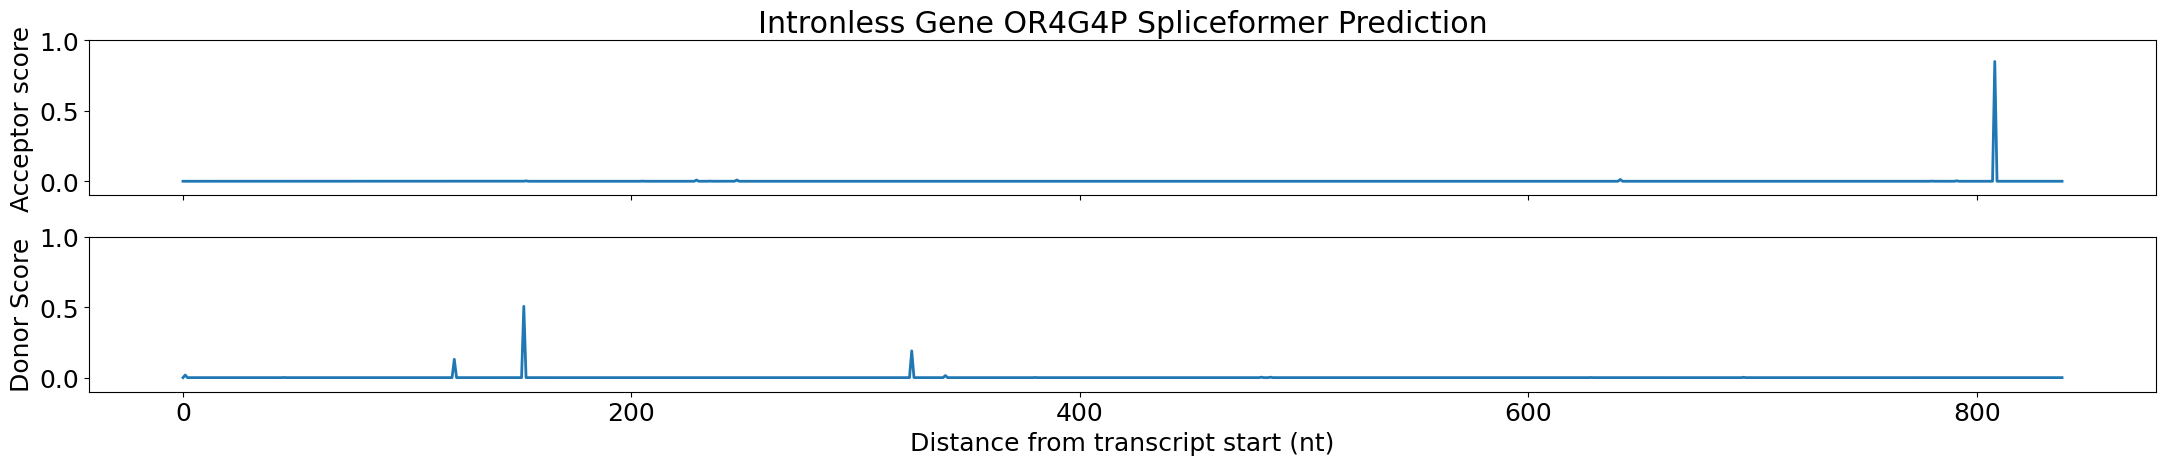

In [16]:
plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(22, 5),sharex=True)
x = np.arange(prediction.shape[1])
ax1.plot(x,prediction[1,:],linewidth=2,zorder=-32)
ax2.plot(x,prediction[2,:],linewidth=2,zorder=-32)
print(prediction[1,:].shape)
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax2.set_ylabel('Donor Score')
ax1.set_title('Intronless Gene OR4G4P Spliceformer Prediction')
ax1.set_ylim([-0.1,1])
ax2.set_ylim([-0.1,1])
plt.tight_layout()
plt.savefig('../Results/Transformer_intronless_prediction.png', dpi=400)
plt.show()
plt.close()

### Now going to test SpliceAI model prediction on intronless gene

In [7]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

In [8]:
padded_sequence, left_padding, right_padding = pad_sequence(sequence,target_length=10000)
one_hot_array = one_hot_encode(padded_sequence)
one_hot_array = torch.tensor(one_hot_array, dtype=torch.float32).T.unsqueeze(0).to(device)
prediction = [models[i](one_hot_array).detach() for i in range(n_models)]
prediction = torch.stack(prediction)
prediction = torch.mean(prediction,dim=0)
acceptor_idxs = torch.argwhere(prediction[0,1,:] > 0.1).detach().numpy()
donor_idxs = torch.argwhere(prediction[0,2,:] > 0.1).detach().numpy()
prediction = prediction[0,:,left_padding:-right_padding]

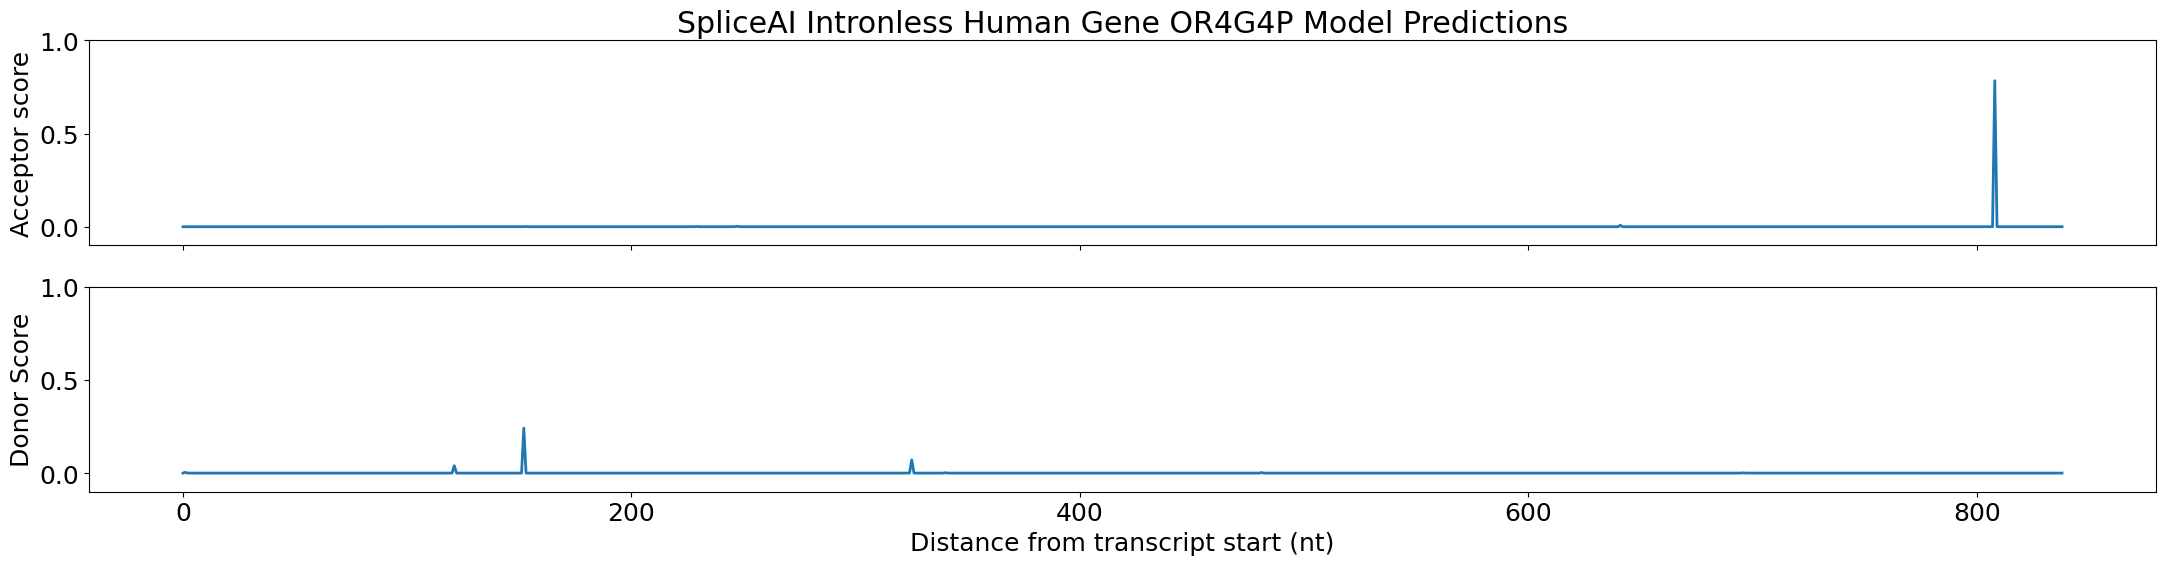

In [9]:
plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(22, 6),sharex=True)

x = np.arange(prediction.shape[1])
ax1.plot(x,prediction[1,:],linewidth=2,zorder=-32)
ax2.plot(x,prediction[2,:],linewidth=2,zorder=-32)

plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax2.set_ylabel('Donor Score')
ax1.set_title('SpliceAI Intronless Human Gene OR4G4P Model Predictions')
ax1.set_ylim([-0.1,1])
ax2.set_ylim([-0.1,1])
plt.tight_layout()
# plt.savefig('../Results/Transformer_CFTR_model_scores_240725.png', dpi=400)
plt.show()
plt.close()

### Generating attention plots for one intronless gene

In [17]:
CL_max=40000
SL=5000
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

models = [copy.deepcopy(model_m) for i in range(n_models)]
#for output_class in [1,2]:
#models = [copy.deepcopy(model_m) for i in range(n_models)]
#[model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_{}'.format(i))) for i,model in enumerate(models)]
#nr = [0,2,3]
#[model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_201221_{}'.format(nr[i]))) for i,model in enumerate(models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

#chunkSize = num_idx/10
for model in models:
    model.eval()

if torch.cuda.device_count() > 1:
    for i in range(n_models):
        for j in range(2):
            for k in range(4):
                models[i].module.transformerBlocks[j].layers[k][0].attend.register_forward_hook(get_activation('attend{}_{}'.format(j*4+k,i)))
else:
    for i in range(n_models):
        for j in range(2):
            for k in range(4):
                models[i].transformerBlocks[j].layers[k][0].attend.register_forward_hook(get_activation('attend{}_{}'.format(j*4+k,i)))

This plotAttentionWeights() function is derived from the one in the get_attention_plots.ipynb notebook.

In [40]:
from collections import defaultdict

def plotAttentionWeights(model_m,batch_features,acceptor_idxs,donor_idxs,left_padding,right_padding):
    start,end = 0,45000
    start_shift = left_padding
    shift = 0
    attentionDict = defaultdict(list)
    for j,model in enumerate(model_m):
        out,acceptor_actions,donor_actions,_,_, = model(batch_features)
        splice_idx = torch.cat([acceptor_actions,donor_actions],dim=1)
        splice_idx = splice_idx.cpu().detach().numpy()[0,:]
        # acceptor_idxs = torch.argwhere(out[0,1,:] > 0.1).detach().numpy()
        # donor_idxs = torch.argwhere(out[0,2,:] > 0.1).detach().numpy()
        if j == 0:
            idxs = np.arange(512)[np.isin(splice_idx,np.concatenate([acceptor_idxs,donor_idxs],0))]
            incl_idxs = splice_idx[idxs]
        else:
            idxs = np.arange(512)[np.isin(splice_idx,np.concatenate([acceptor_idxs,donor_idxs],0))]
            incl_idxs = np.concatenate([incl_idxs,splice_idx[idxs]],axis=0)
        attention = np.concatenate([activation['attend{}_{}'.format(i,j)][0,:,:,:].cpu().numpy() for i in range(8)],axis=0)
        for i,idx in enumerate(idxs):
            attentionExpanded = np.zeros((end))
            attentionExpanded[splice_idx] = np.mean(attention[:,idx,:],axis=0)
            attentionDict[incl_idxs[i]].append(attentionExpanded)
    for i,key in enumerate(attentionDict.keys()):
        attentionExpanded = np.mean(attentionDict[key],axis=0)
        fig = plt.figure(figsize=(22, 4))
        val = int(key)
        plt.plot(attentionExpanded[left_padding:-right_padding])
        a = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=start, acceptor_idxs<=end))]
        plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[a],attentionExpanded[a]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Predicted\nAcceptor')
        d = donor_idxs[np.where(np.logical_and(donor_idxs>=start, donor_idxs<=end))]
        plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[d],attentionExpanded[d]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Predicted\nDonor')
        plt.scatter(val+shift-start_shift,attentionExpanded[val]+0.01,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
        plt.legend(prop={'size': 10})
        plt.xlabel('Directed distance from transcript start (nt)')
        plt.ylabel('Attention')
        plt.tight_layout()
        plt.title('Intronless Gene OR4G4P Attention Scores')
        if i == 0:
            plt.savefig('../Results/AttentionPlotsOR4G4P_intronless_{}.png'.format(key), dpi=400,bbox_inches='tight')
        plt.show()
        plt.close()

        # Just zooming in on each plot
        # fig = plt.figure(figsize=(22, 3))
        # plt.plot(attentionExpanded[val-100:val+100])
        # a = acceptor_idxs[np.where(np.logical_and(acceptor_idxs>=start, acceptor_idxs<=end))]
        # plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[a],attentionExpanded[a]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Predicted\nAcceptor')
        # d = donor_idxs[np.where(np.logical_and(donor_idxs>=start, donor_idxs<=end))]
        # plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[d],attentionExpanded[d]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Predicted\nDonor')
        # plt.scatter(val+shift-start_shift,attentionExpanded[val]+0.01,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
        # plt.legend(prop={'size': 10})
        # plt.xlabel('Directed distance from transcript start (nt)')
        # plt.ylabel('Attention')
        # plt.tight_layout()
        # # plt.savefig('../Results/AttentionPlots_240725/{}_{}_{}.png'.format(name,start+shift+val,shift), dpi=400)
        # plt.show()
        # plt.close()



    return incl_idxs

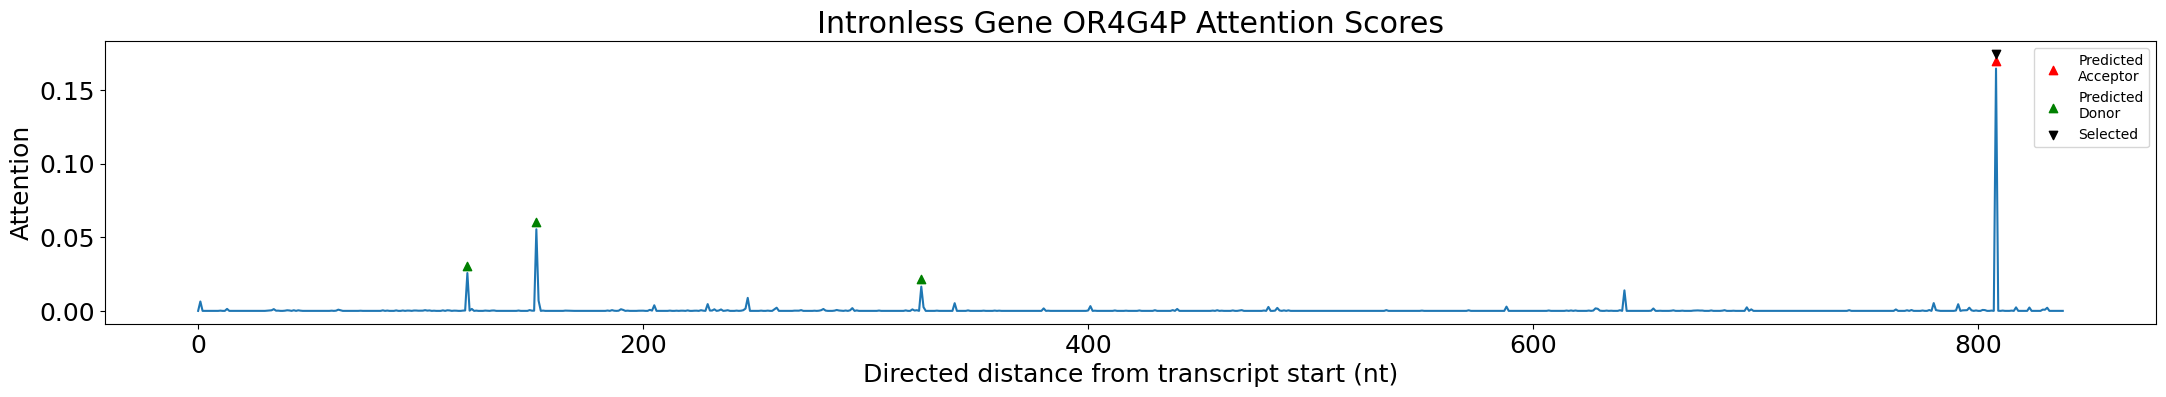

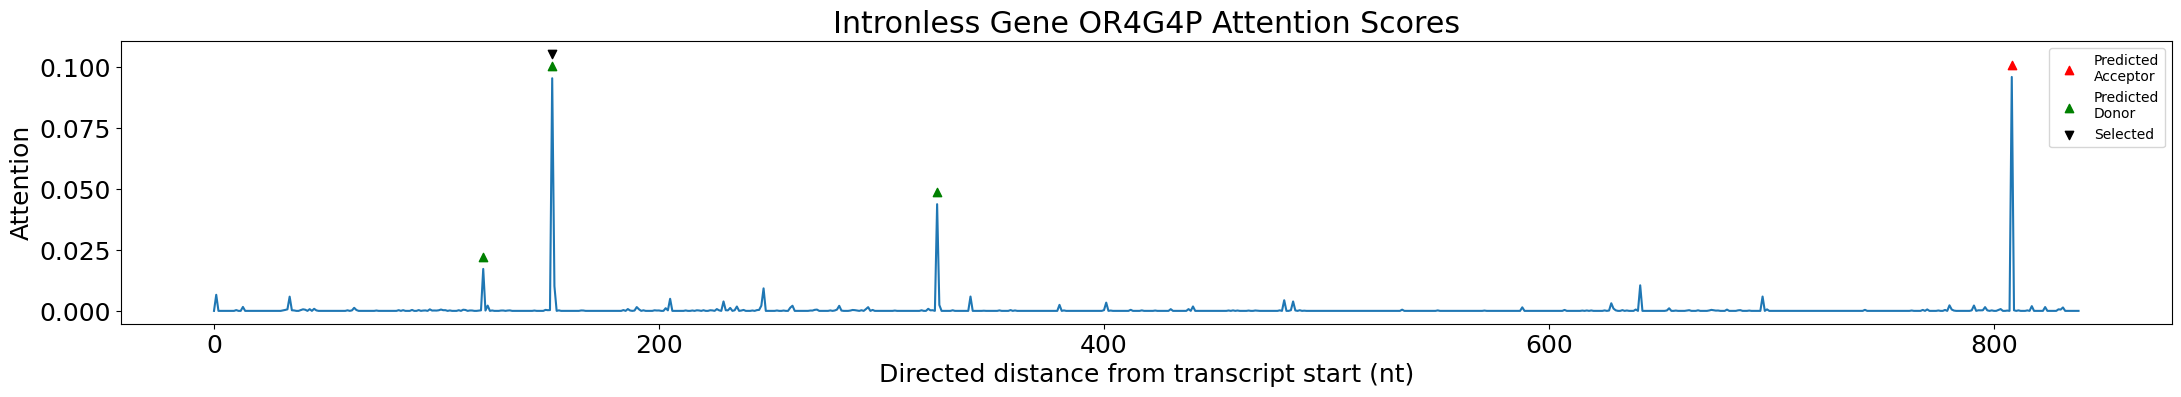

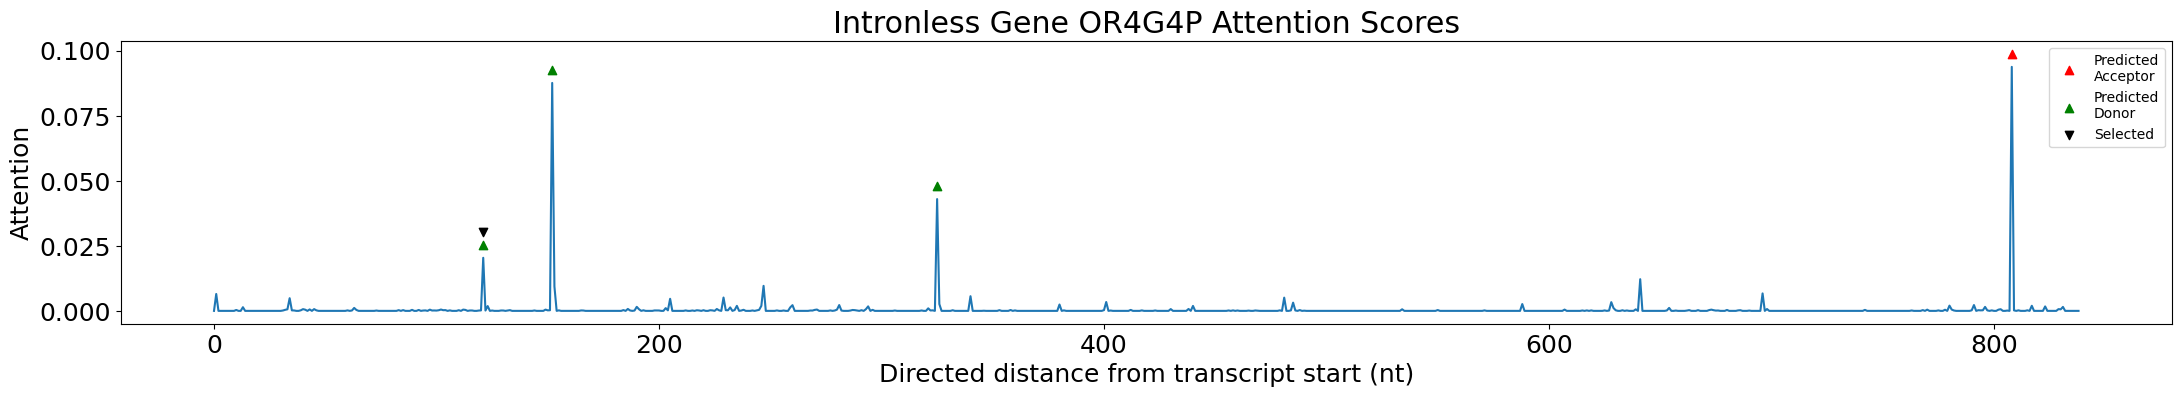

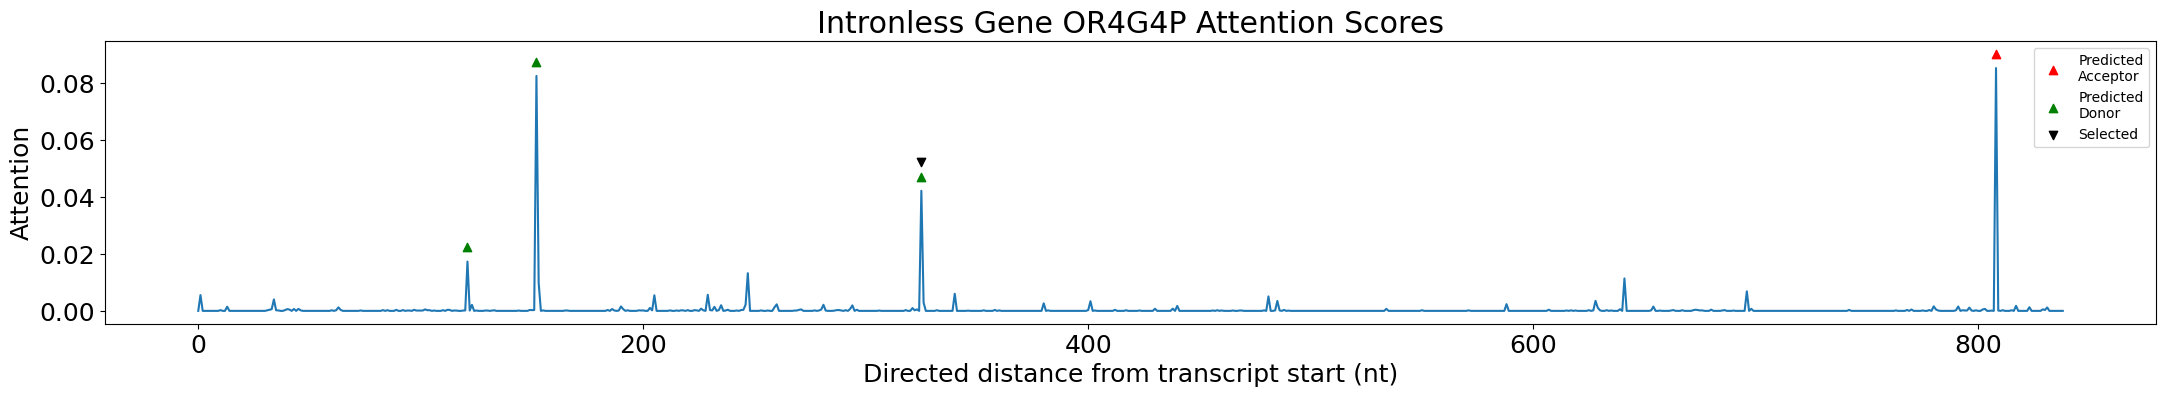

array([22888, 22232, 22201, 22405, 22888, 22232, 22201, 22405, 22888,
       22232, 22405, 22201, 22888, 22405, 22232, 22201, 22888, 22201,
       22405, 22232, 22888, 22232, 22201, 22405, 22888, 22232, 22201,
       22405, 22888, 22232, 22405, 22201, 22888, 22232, 22201, 22405,
       22888, 22232, 22201, 22405])

In [41]:
plotAttentionWeights(models,one_hot_array,acceptor_idxs,donor_idxs,left_padding,right_padding)

### Now want to apply Grad-CAM to this specific intronless transcript

This was an earlier iteration of my grad-cam implementation, where I only considered a single layer

In [15]:
from collections import OrderedDict
from collections import defaultdict
# import torch.nn.functional as F
activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)
    

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    models[i].SpliceAI.register_forward_hook(forward_hook)
    models[i].SpliceAI.register_full_backward_hook(backward_hook)


In [45]:
def plot_single(grad_cam,model,label,idx):
    relu = torch.nn.ReLU()
    grad_cam = relu(grad_cam)
    grad_cam = grad_cam.detach().numpy()
    if grad_cam.max() != np.float32(0):
        grad_cam /= grad_cam.max()
    plt.figure(figsize=(15, 3))
    plt.plot(grad_cam, label='Grad-CAM Heatmap')
    plt.scatter(idx, grad_cam[idx],c='green' if label==1 else 'red',marker="^", clip_on=False, zorder=10,label='Donor' if label==1 else 'Acceptor')

    plt.xlabel('Position in Sequence')
    plt.ylabel('Importance')
    plt.title(f'{model}-model Grad-CAM Visualization Over Sequence')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

In [14]:
def plot_GradCAM(models,batch_features,donor_idxs,acceptor_idxs,left_padding,right_padding):
    grad_cam_dict = defaultdict(list)
    # grad_cam_full = []
    for j,model in enumerate(models):
        donor_vals = donor_idxs.flatten()
        acceptor_vals = acceptor_idxs.flatten()
        labels = np.array([0] * len(acceptor_vals) + [1] * len(donor_vals))
        positions = np.concatenate((acceptor_vals, donor_vals))
        splice_idxs = (labels, positions)
        activations.clear()
        gradients.clear()
        for label,idx in zip(splice_idxs[0],splice_idxs[1]):
            activations.clear()
            gradients.clear()
            output = model(batch_features)
            target = output[0][0,label+1,idx]
            model.zero_grad()
            target.backward()
            avg_grad = torch.mean(gradients[0][0], dim=(0,2))
            activation_reduced = torch.mean(activations[0],dim=0)
            weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
            grad_cam = torch.sum(weighted_activations, dim=0)
            # plot_single(grad_cam,j,label,idx)
            grad_cam_dict[idx].append(grad_cam)
            # grad_cam_full.append(grad_cam)
    for label,key in zip(splice_idxs[0],splice_idxs[1]):
        grad_cam_key = torch.stack(grad_cam_dict[key])
        grad_cam_key = torch.mean(grad_cam_key,dim=0)
        # grad_cam_key = grad_cam_key[1]
        relu = torch.nn.ReLU()
        grad_cam_key = relu(grad_cam_key)
        grad_cam_key = grad_cam_key.detach().numpy()
        if grad_cam_key.max() != np.float32(0):
            grad_cam_key /= grad_cam_key.max()
        
        fig = plt.figure(figsize=(22, 3))

        plt.plot(grad_cam_key[left_padding:-right_padding], label='Grad-CAM Heatmap')
        if label == 1:
            plt.scatter(np.arange(0-left_padding,45000-left_padding)[donor_idxs], grad_cam_key[donor_idxs]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
        elif label == 0:
            plt.scatter(np.arange(0-left_padding,45000-left_padding)[acceptor_idxs], grad_cam_key[acceptor_idxs]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

        plt.scatter(key-left_padding, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')
        plt.xlabel('Position in Sequence')
        plt.ylabel('Grad-CAM score')
        plt.legend(prop={'size': 10})
        plt.tight_layout()
        plt.show()
        plt.close()

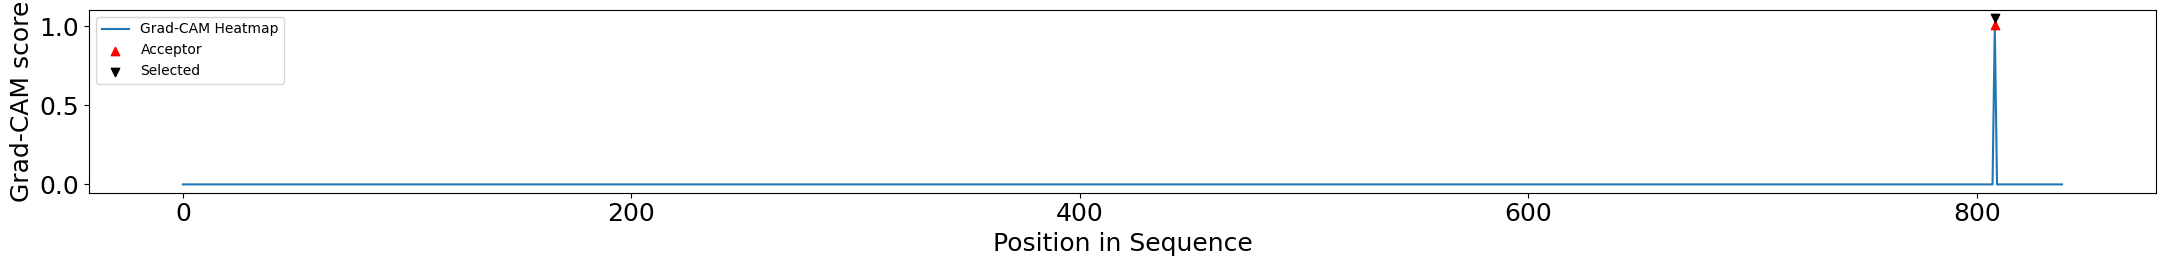

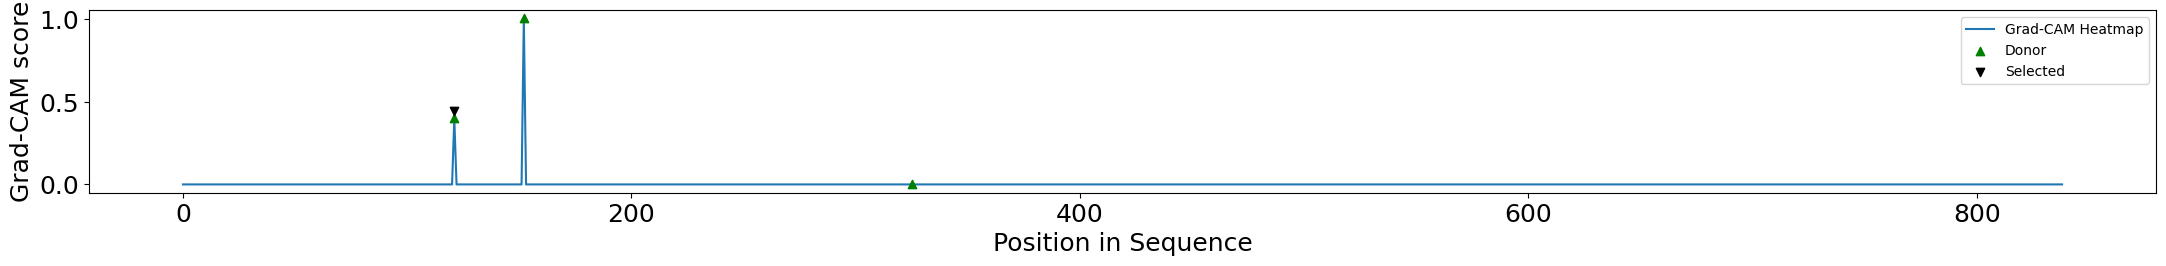

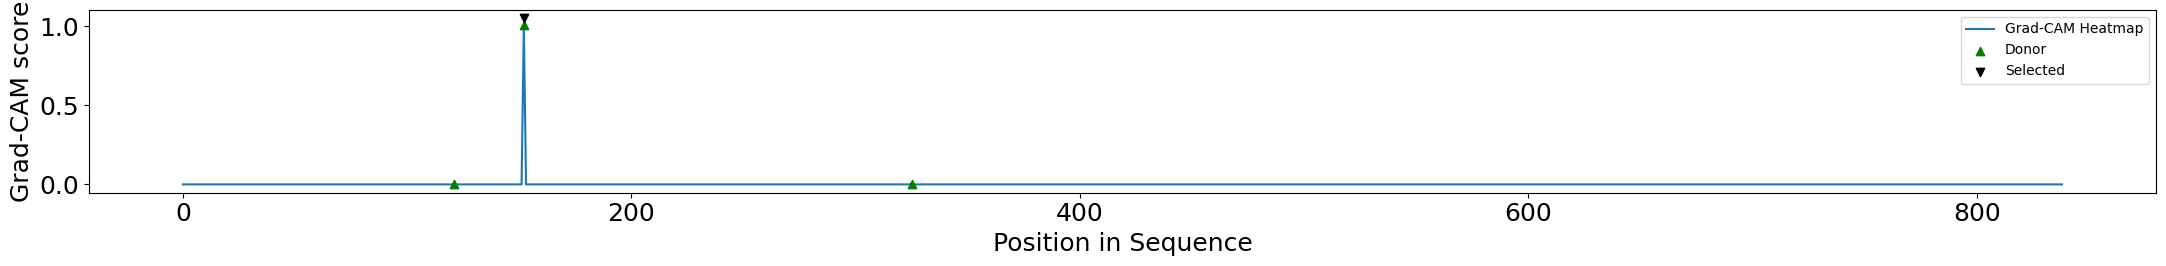

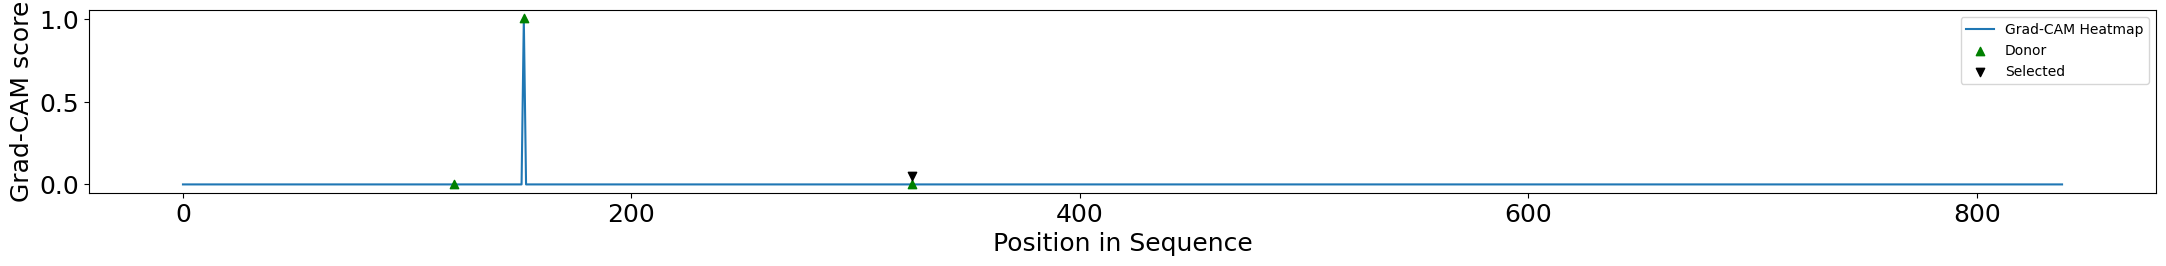

In [12]:
plot_GradCAM(models,one_hot_array,donor_idxs,acceptor_idxs)

### Testing on another intronless transcript

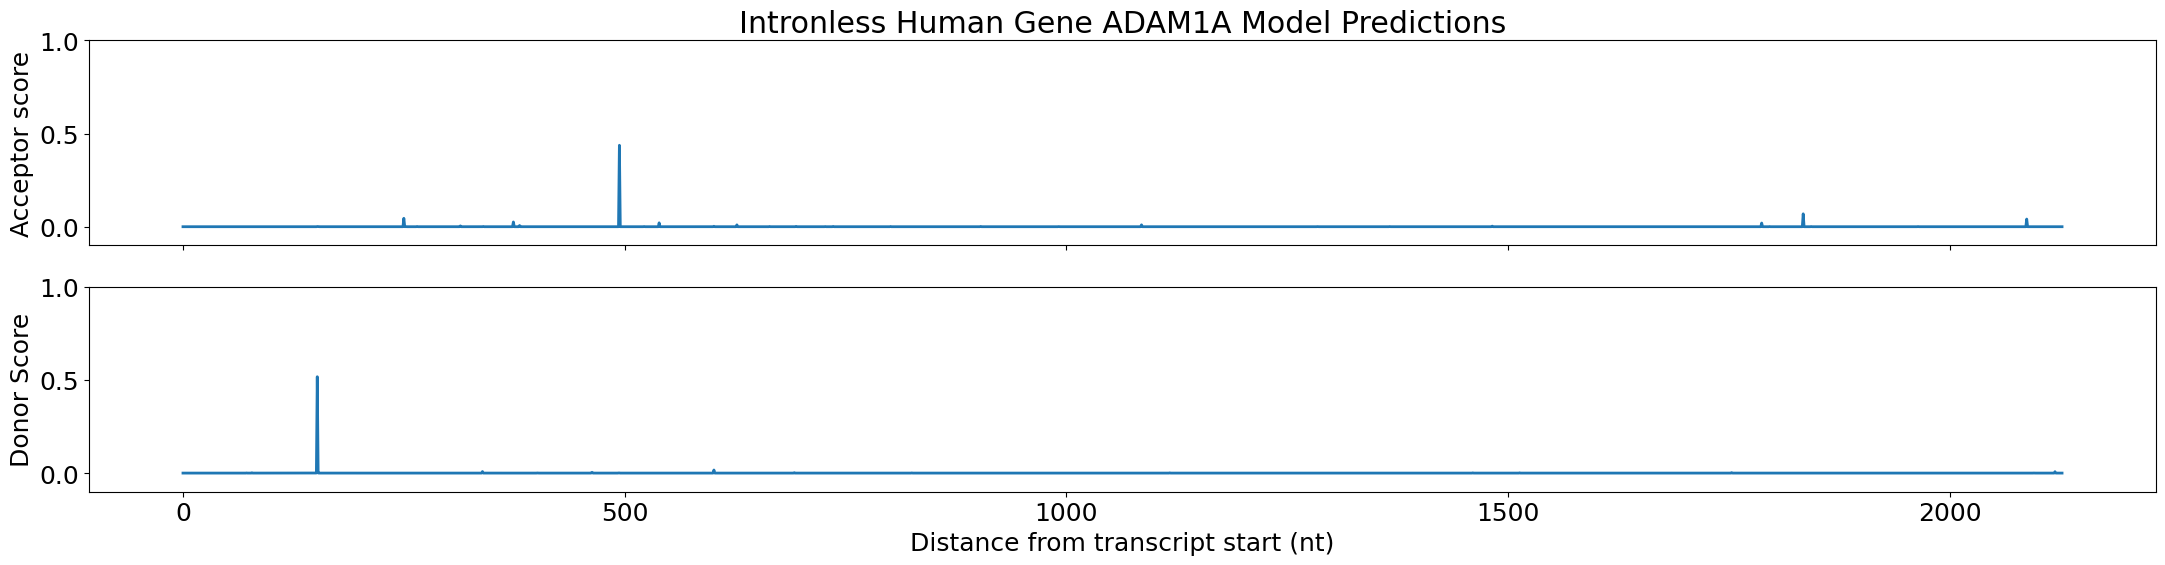

In [16]:
sequence = str(fasta['chr12'][111899263:111901391])
padded_sequence, left_padding, right_padding = pad_sequence(sequence,target_length=45000)
one_hot_array = one_hot_encode(padded_sequence)
one_hot_array = torch.tensor(one_hot_array, dtype=torch.float32).T.unsqueeze(0).to(device)
prediction = [models[i](one_hot_array)[0].detach() for i in range(n_models)]
prediction = torch.stack(prediction)
prediction = torch.mean(prediction,dim=0)
acceptor_idxs = torch.argwhere(prediction[0,1,:] > 0.1).detach().numpy()
donor_idxs = torch.argwhere(prediction[0,2,:] > 0.1).detach().numpy()
prediction = prediction[0,:,left_padding:-right_padding]

plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(22, 6),sharex=True)

x = np.arange(prediction.shape[1])
ax1.plot(x,prediction[1,:],linewidth=2,zorder=-32)
ax2.plot(x,prediction[2,:],linewidth=2,zorder=-32)

plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax2.set_ylabel('Donor Score')
ax1.set_title('Intronless Human Gene ADAM1A Model Predictions')
ax1.set_ylim([-0.1,1])
ax2.set_ylim([-0.1,1])
plt.tight_layout()
# plt.savefig('../Results/Transformer_CFTR_model_scores_240725.png', dpi=400)
plt.show()
plt.close()

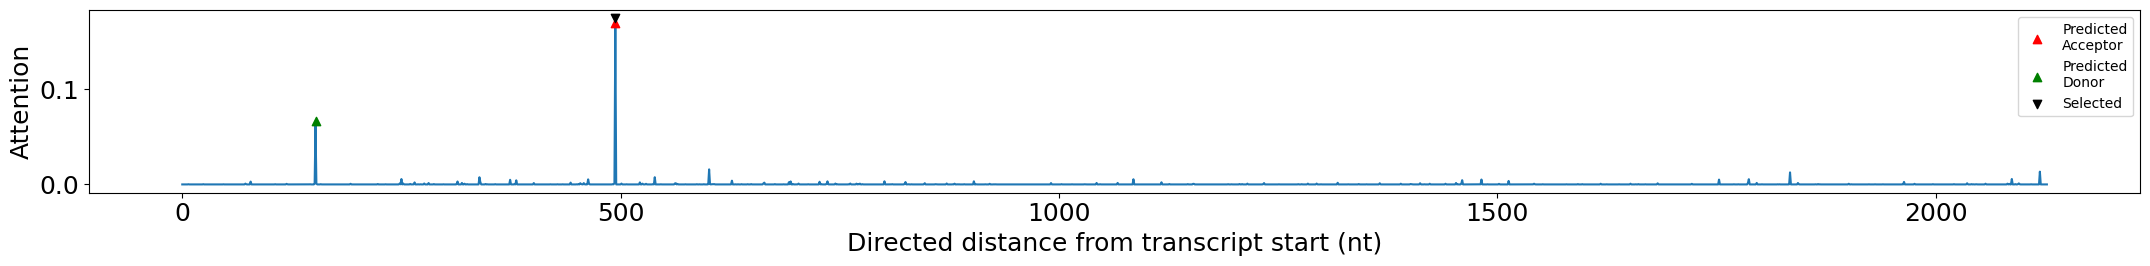

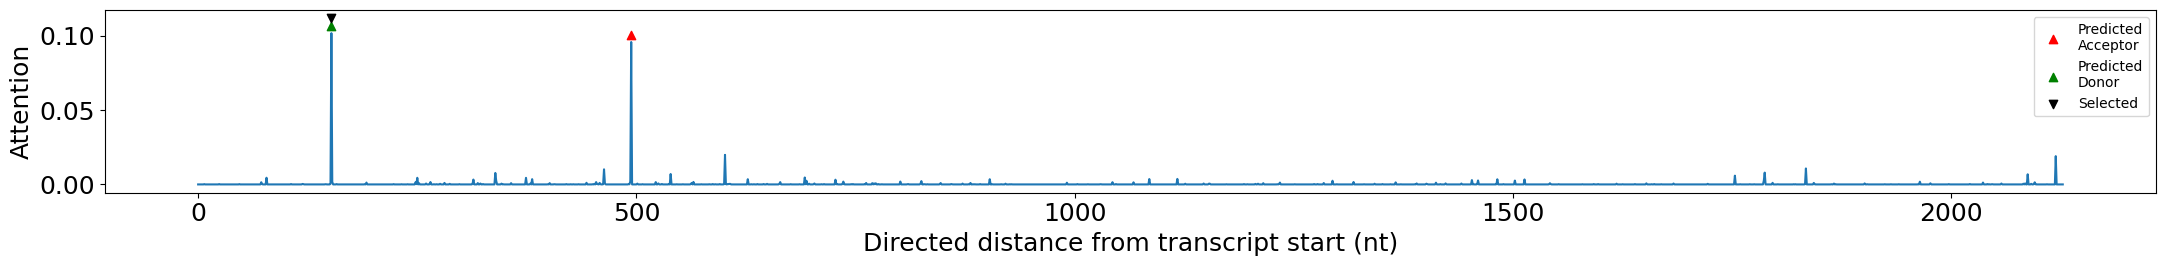

array([21930, 21588, 21930, 21588, 21930, 21588, 21930, 21588, 21930,
       21588, 21930, 21588, 21930, 21588, 21930, 21588, 21930, 21588,
       21930, 21588])

In [30]:
plotAttentionWeights(models,one_hot_array,'a',acceptor_idxs,donor_idxs,left_padding,right_padding)

In [11]:
from collections import OrderedDict
from collections import defaultdict
# import torch.nn.functional as F
activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)
    

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    models[i].SpliceAI.register_forward_hook(forward_hook)
    models[i].SpliceAI.register_full_backward_hook(backward_hook)

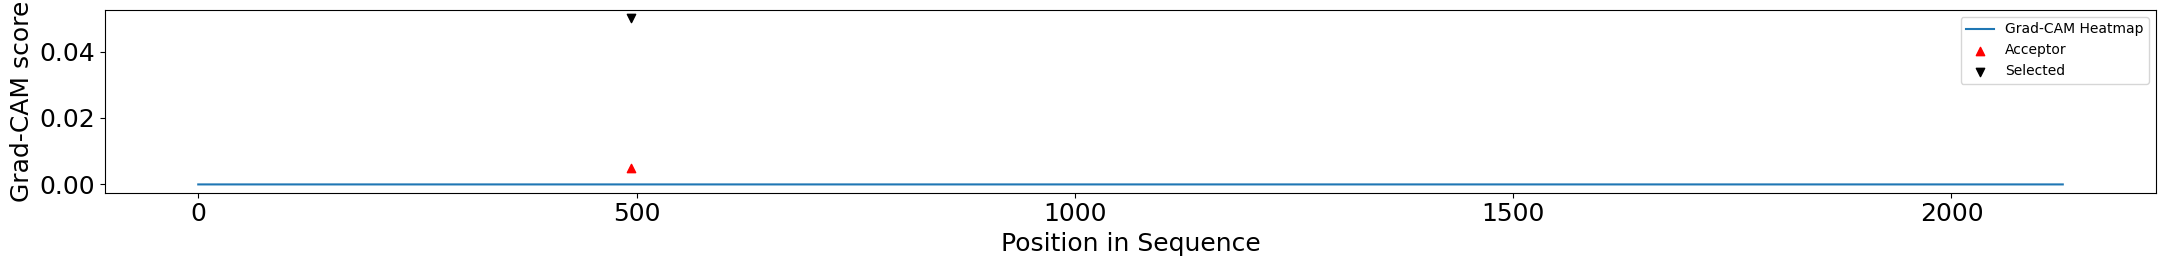

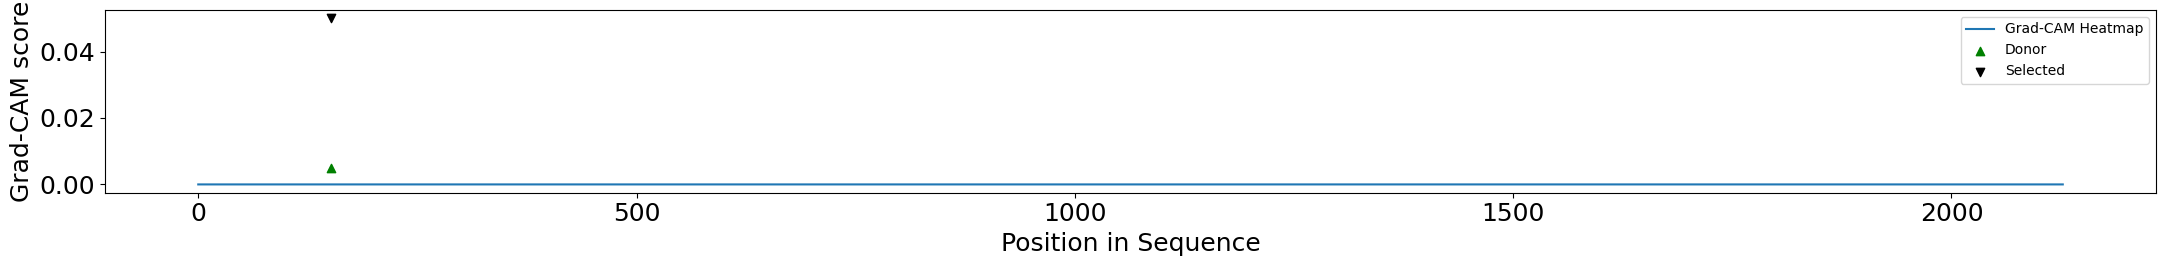

In [17]:
plot_GradCAM(models,one_hot_array,donor_idxs,acceptor_idxs,left_padding,right_padding)